In [116]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

-0.0555152736108447 0.987723445500014
0.0028507143486956087 0.9853861838098944
-0.03710133874313446 0.8602006870616183
-0.039992369337265625 0.9187914902512285


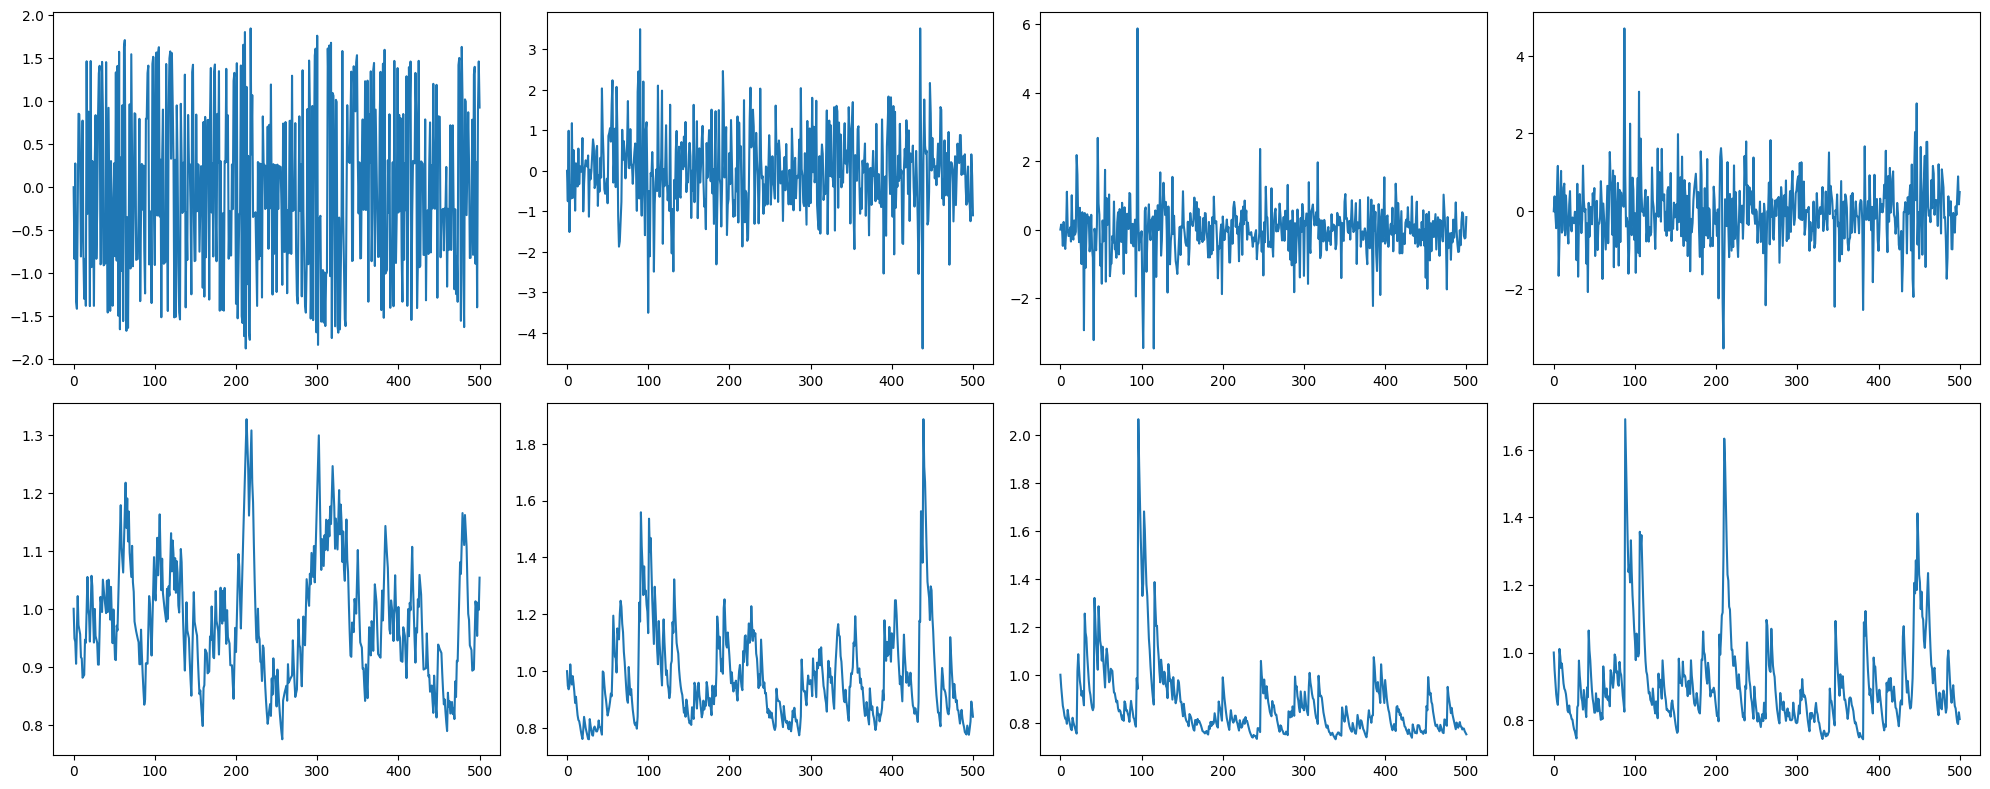

In [150]:
#a
n = 500
z_t = np.random.randint(1,6+1,size=n+1)
z = (z_t-7/2)/np.sqrt(70/24)
z2 = np.random.normal(0,1,size=n+1)
z3 = np.random.standard_t(df=3,size=n+1)/(np.sqrt(3/(3-2)))
z4 = np.random.standard_t(df=5,size=n+1)/(np.sqrt(4/(4-2)))

print(np.mean(z),np.std(z,ddof=1))
print(np.mean(z2),np.std(z2,ddof=1))
print(np.mean(z3),np.std(z3,ddof=1))
print(np.mean(z4),np.std(z4,ddof=1))


#b

def gen_garch11(alpha0=0.1,alpha1=0.1,beta=0.8,z=np.random.normal(0,1,100)):
    n = len(z)
    sigma = np.zeros(shape=(n))
    x = np.zeros(shape=(n))
    sigma[0] = np.sqrt(alpha0/(1-alpha1-beta))
    for i in range(1,n):
        sigma[i] = np.sqrt(alpha0+alpha1*x[i-1]**2+beta*sigma[i-1]**2)
        x[i] = sigma[i]*z[i]

    return x,sigma

alpha0=0.1;alpha1=0.1;beta=0.8

x1,s1 = gen_garch11(alpha0,alpha1,beta,z)
x2,s2 = gen_garch11(alpha0,alpha1,beta,z2)
x3,s3 = gen_garch11(alpha0,alpha1,beta,z3)
x4,s4 = gen_garch11(alpha0,alpha1,beta,z4)

plt.figure(figsize=(20,8))
plt.subplot(2,4,1)
plt.plot(x1)
plt.subplot(2,4,2)
plt.plot(x2)
plt.subplot(2,4,3)
plt.plot(x3)
plt.subplot(2,4,4)
plt.plot(x4)

plt.subplot(2,4,5)
plt.plot(s1)
plt.subplot(2,4,6)
plt.plot(s2)
plt.subplot(2,4,7)
plt.plot(s3)
plt.subplot(2,4,8)
plt.plot(s4)

plt.tight_layout()
plt.show()

